# Instance Segmentation with MATA

Demonstrates `VisionResult` (segmentation) auto-display with mask information.

**Model used**: `facebook/mask2former-swin-tiny-coco-instance`

**Prerequisites**: `pip install datamata[notebook,eval]`

In [ ]:
# !pip install datamata[notebook,eval]

In [1]:
import mata
from pathlib import Path

print(f"MATA version: {mata.__version__}")

IMAGE_1 = "../../examples/images/000000039769.jpg"
IMAGE_2 = "../../examples/images/000000015338.jpg"

for label, p in [("image 1", IMAGE_1), ("image 2", IMAGE_2)]:
    status = "✅ FOUND" if Path(p).exists() else "❌ NOT FOUND"
    print(f"  {label:10s}: {status}")

MATA version: 1.9.5
  image 1   : ✅ FOUND
  image 2   : ✅ FOUND


In [3]:
# Create a runs folder for saving outputs
runs_dir = Path("../..") / "runs" / "segmentation"
runs_dir.mkdir(parents=True, exist_ok=True)


In [4]:
segmenter = mata.load("segment", "facebook/mask2former-swin-tiny-coco-panoptic")

[INFO] Loading segment model from huggingface: facebook/mask2former-swin-tiny-coco-panoptic
[INFO] Auto-selected CUDA device (NVIDIA GeForce RTX 3070)
[INFO] Initialized HuggingFaceSegmentAdapter with device=cuda, threshold=0.5
[INFO] Loading segmentation model: facebook/mask2former-swin-tiny-coco-panoptic
[INFO] Detected architecture: mask2former, mode: panoptic
[INFO] Using segmentation mode: panoptic
[WARNING] Model config missing 'is_thing_map' for panoptic segmentation. All classes will be treated as instances (is_stuff=False).
[INFO] Loaded mask2former model on cuda (mode=panoptic, labels=133)


[INFO] Running panoptic segmentation on 640x480 image


`label_ids_to_fuse` unset. No instance will be fused.


[INFO] Found 5 segments (5 instances, 0 stuff)
[INFO] Visualizing 5 instances (VisionResult) with pil backend (alpha=0.5)


Label,Score,BBox
couch,0.822,"(0, 0, 639, 479)"
remote,0.954,"(335, 77, 370, 187)"
remote,0.994,"(40, 74, 175, 115)"
cat,0.998,"(345, 27, 639, 370)"
cat,0.997,"(10, 56, 314, 474)"

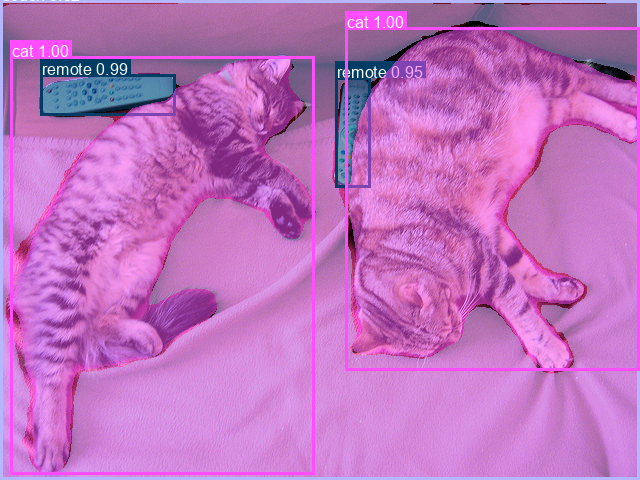

In [5]:
IMAGE = "../../examples/images/000000039769.jpg"
result = segmenter.predict(IMAGE) 

# Auto-display: instance table
result

[INFO] Visualizing 5 instances (VisionResult) with pil backend (alpha=0.5)


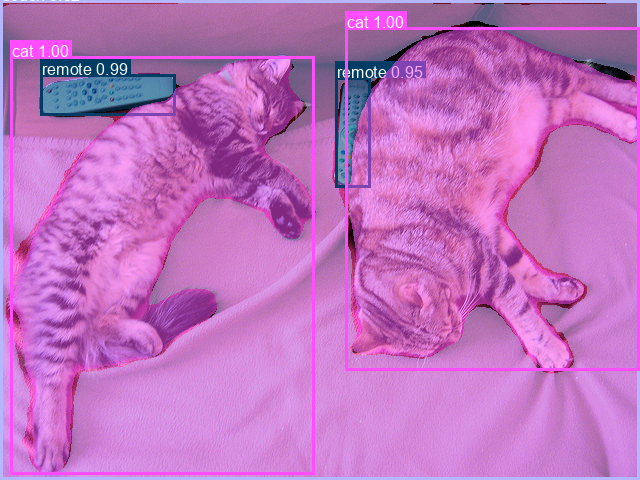

Saved to: ..\..\runs\segmentation\segmentation_panoptic.png


In [6]:
# Visualize segmentation masks as a coloured overlay
vis = mata.visualize_segmentation(result, IMAGE)
output_path = runs_dir / "segmentation_panoptic.png"
mata.show(vis, save=str(output_path))
print(f"Saved to: {output_path}")


In [7]:
# Count masks vs stuff regions
print(f"Instances: {len(result.get_instances())}")
print(f"Stuff regions: {len(result.get_stuff())}")

Instances: 5
Stuff regions: 0


## Load other model

In [8]:
segmenter = mata.load("segment", "facebook/mask2former-swin-tiny-coco-instance")

[INFO] Loading segment model from huggingface: facebook/mask2former-swin-tiny-coco-instance
[INFO] Auto-selected CUDA device (NVIDIA GeForce RTX 3070)
[INFO] Initialized HuggingFaceSegmentAdapter with device=cuda, threshold=0.5
[INFO] Loading segmentation model: facebook/mask2former-swin-tiny-coco-instance
[INFO] Detected architecture: mask2former, mode: instance
[INFO] Using segmentation mode: instance
[INFO] Loaded mask2former model on cuda (mode=instance, labels=80)


[INFO] Running instance segmentation on 640x480 image
[INFO] Found 5 segments (5 instances, 0 stuff)
[INFO] Visualizing 5 instances (VisionResult) with pil backend (alpha=0.5)


Label,Score,BBox
cat,0.967,"(345, 28, 639, 369)"
remote,0.982,"(40, 75, 174, 117)"
cat,0.961,"(12, 57, 316, 471)"
couch,0.894,"(0, 0, 639, 479)"
remote,0.936,"(334, 78, 368, 186)"

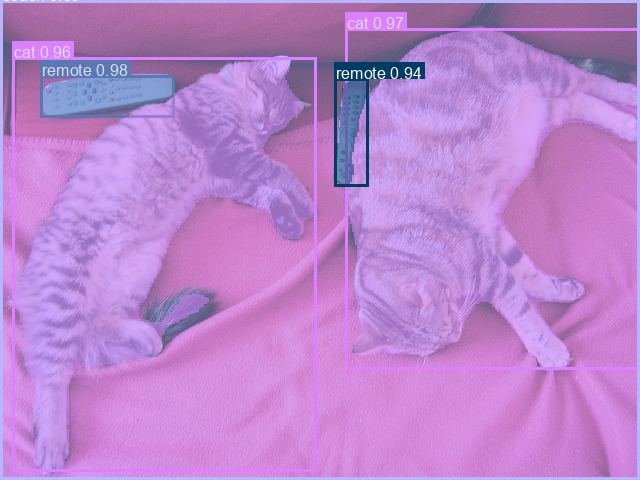

In [9]:
result = segmenter.predict(IMAGE)  # fuse person and bicycle into one instance

# Auto-display: instance table
result

[INFO] Visualizing 5 instances (VisionResult) with pil backend (alpha=0.5)


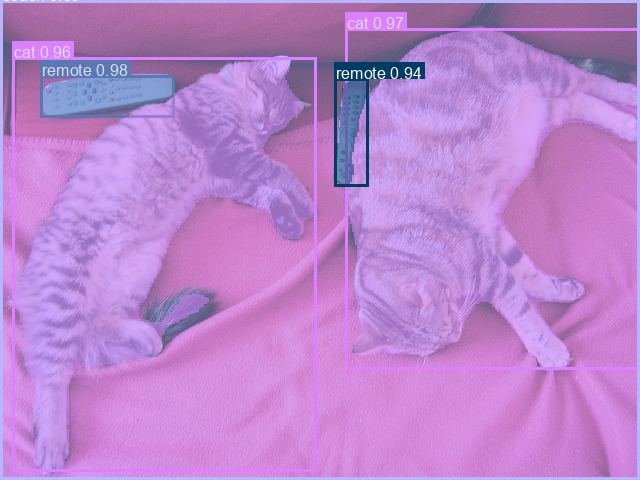

Saved to: ..\..\runs\segmentation\segmentation_instance.png


In [10]:
# Visualize segmentation masks as a coloured overlay
vis = mata.visualize_segmentation(result, IMAGE)
output_path = runs_dir / "segmentation_instance.png"
mata.show(vis, save=str(output_path))
print(f"Saved to: {output_path}")


In [11]:
# Count masks vs stuff regions
print(f"Instances: {len(result.get_instances())}")
print(f"Stuff regions: {len(result.get_stuff())}")

Instances: 5
Stuff regions: 0


## Notes

- The auto-display table shows label, score, and bbox for each instance
- `mata.visualize_segmentation()` produces a colourised overlay image
- `result.get_instances()` / `result.get_stuff()` split panoptic results